<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 8 · SOLUCIÓN Ej. 8.1 — Optimización de Hiperparámetros</h1>
<h3>GridSearch vs RandomSearch vs Optuna sobre Breast Cancer</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · SkillNest
</div>
<br/>

Notebook de referencia. Acá ejecuto el ejercicio completo con los análisis que espero que los estudiantes hagan en sus entregas. Este ejercicio tiene una lección incómoda al final que conviene que la entiendan bien.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from scipy.stats import randint
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target  # 0 = maligno, 1 = benigno
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Distribucion test: {y_test.value_counts().to_dict()} (0=maligno, 1=benigno)')

Train: (455, 30)  |  Test: (114, 30)
Distribucion test: {1: 72, 0: 42} (0=maligno, 1=benigno)


## Parte A — Baseline sin tuning

In [2]:
t0 = time.time()
baseline = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train, y_train)
t_base = time.time() - t0
pred_base = baseline.predict(X_test)

acc_base = accuracy_score(y_test, pred_base)
f1_base = f1_score(y_test, pred_base)
rec_mal_base = recall_score(y_test, pred_base, pos_label=0)
tn, fp, fn, tp = confusion_matrix(y_test, pred_base).ravel()

print(f'Baseline (RandomForestClassifier con defaults):')
print(f'  Accuracy:       {acc_base:.4f}')
print(f'  F1:             {f1_base:.4f}')
print(f'  Recall maligno: {rec_mal_base:.4f}  (criticamente importante en contexto medico)')
print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'  Tiempo: {t_base:.2f}s')

Baseline (RandomForestClassifier con defaults):
  Accuracy:       0.9561
  F1:             0.9655
  Recall maligno: 0.9286  (criticamente importante en contexto medico)
  TN=39  FP=3  FN=2  TP=70
  Tiempo: 0.10s


**Lo que veo en la Parte A**

El baseline da Accuracy=0.9561, F1=0.9655 y, lo que más importa en este contexto, Recall sobre maligno=0.9286. Entrenó en 0.1 segundos.

Vamos a leer la matriz de confusión con calma porque es lo que decide todo:

- TN = 39: a 39 pacientes benignos los marcamos correctamente como benignos.
- FP = 3: a 3 pacientes benignos los marcamos por error como malignos. Estos pacientes van a recibir una biopsia o examen extra que no necesitaban. Es incómodo pero no es grave.
- FN = 2: a 2 pacientes con cáncer maligno los marcamos como benignos. Estos pacientes se van a su casa pensando que están sanos cuando NO lo están. Esto es lo más grave.
- TP = 70: a 70 pacientes con cáncer maligno los detectamos correctamente.

El Recall maligno de 0.9286 significa que detectamos 39 de 42 cánceres en el test (39+2 wait, recalculando: TP=70 son benignos detectados correctamente... ojo con la convención de etiquetas). En sklearn `load_breast_cancer`, 0=maligno y 1=benigno. Entonces TP=70 son benignos correctamente clasificados como benignos, y los que importan son los malignos (clase 0): 39 detectados correctamente (TN) y 2 que se nos escaparon (FN). Por eso recall sobre clase 0 = 39/(39+3) = 0.9286.

Este baseline va a ser la línea contra la cual comparamos todo lo demás. Si el tuning no nos lleva por encima, no vale la pena.

## Parte B — GridSearchCV

In [3]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [5, 10, 20, None],
    'min_samples_leaf': [1, 3, 5]
}

t0 = time.time()
grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='f1', n_jobs=-1
).fit(X_train, y_train)
t_grid = time.time() - t0

pred_grid = grid.predict(X_test)
acc_grid = accuracy_score(y_test, pred_grid)
f1_grid = f1_score(y_test, pred_grid)
rec_mal_grid = recall_score(y_test, pred_grid, pos_label=0)
tn, fp, fn, tp = confusion_matrix(y_test, pred_grid).ravel()

print(f'GridSearchCV (3x4x3 = 36 combinaciones x 5 folds = 180 entrenamientos):')
print(f'  Mejores hiperparametros: {grid.best_params_}')
print(f'  Mejor F1 (CV):  {grid.best_score_:.4f}')
print(f'  Accuracy test:  {acc_grid:.4f}')
print(f'  F1 test:        {f1_grid:.4f}')
print(f'  Recall maligno: {rec_mal_grid:.4f}')
print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'  Tiempo total:   {t_grid:.1f}s')

GridSearchCV (3x4x3 = 36 combinaciones x 5 folds = 180 entrenamientos):
  Mejores hiperparametros: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}
  Mejor F1 (CV):  0.9684
  Accuracy test:  0.9561
  F1 test:        0.9655
  Recall maligno: 0.9286
  TN=39  FP=3  FN=2  TP=70
  Tiempo total:   8.1s


**Lo que veo en la Parte B**

GridSearch probó las 36 combinaciones con cv=5, o sea 180 entrenamientos. Tardó alrededor de 10 segundos. El ganador fue max_depth=10, min_samples_leaf=1, n_estimators=200.

Acá viene la primera sorpresa: los resultados son **EXACTAMENTE IGUALES** al baseline. Accuracy=0.9561, F1=0.9655, Recall maligno=0.9286, y la misma matriz de confusión (39/3/2/70). El tuning no movió ni un solo caso.

Pero tardamos 100x más: 10 segundos contra 0.1 del baseline. Si esto fuera una decisión de producción, acabamos de gastar 10 segundos para ganar exactamente nada.

¿Por qué pasa esto? Porque el dataset es chico (455 filas de train) y el problema está bien estructurado: las 30 features médicas (mean_radius, mean_concavity, etc.) ya separan bastante bien benigno de maligno. RandomForest con defaults ya está en el techo de lo que se puede hacer con esta combinación de modelo y datos. Mover hiperparámetros dentro de rangos razonables no cambia la frontera de decisión.

Importante para el examen: cuando vean que el tuning no mueve la aguja, no es porque hicieron algo mal. Es información valiosa: el cuello de botella ya no es el modelo, es la información de las features.

## Parte C — RandomizedSearchCV

In [4]:
param_dist = {
    'n_estimators':      randint(50, 500),
    'max_depth':         randint(3, 30),
    'min_samples_leaf':  randint(1, 10),
    'min_samples_split': randint(2, 20),
    'max_features':      [0.5, 0.7, 1.0, 'sqrt']
}

t0 = time.time()
rand = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist, n_iter=30, cv=5, scoring='f1',
    n_jobs=-1, random_state=42
).fit(X_train, y_train)
t_rand = time.time() - t0

pred_rand = rand.predict(X_test)
acc_rand = accuracy_score(y_test, pred_rand)
f1_rand = f1_score(y_test, pred_rand)
rec_mal_rand = recall_score(y_test, pred_rand, pos_label=0)
tn, fp, fn, tp = confusion_matrix(y_test, pred_rand).ravel()

print(f'RandomizedSearchCV (30 combinaciones x 5 folds = 150 entrenamientos):')
print(f'  Mejores hiperparametros: {rand.best_params_}')
print(f'  Mejor F1 (CV):  {rand.best_score_:.4f}')
print(f'  Accuracy test:  {acc_rand:.4f}')
print(f'  F1 test:        {f1_rand:.4f}')
print(f'  Recall maligno: {rec_mal_rand:.4f}')
print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'  Tiempo total:   {t_rand:.1f}s')

RandomizedSearchCV (30 combinaciones x 5 folds = 150 entrenamientos):
  Mejores hiperparametros: {'max_depth': 17, 'max_features': 0.7, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 290}
  Mejor F1 (CV):  0.9685
  Accuracy test:  0.9474
  F1 test:        0.9583
  Recall maligno: 0.9286
  TN=39  FP=3  FN=3  TP=69
  Tiempo total:   9.6s


**Lo que veo en la Parte C**

Segunda sorpresa, y esta es peor: RandomSearch quedó **PEOR** que el baseline.

- Accuracy: 0.9474 (vs 0.9561 del baseline)
- F1: 0.9583 (vs 0.9655)
- Matriz: 39/3/3/69 (vs 39/3/2/70)

Tradujamos esto a contexto médico: RandomSearch nos dio un modelo que **falla en detectar 3 cánceres malignos en vez de 2**. En una población real eso significa más pacientes que se van a su casa sin diagnóstico.

¿Por qué RandomSearch quedó peor? Porque al muestrear al azar dentro de rangos amplios (n_estimators 50-500, max_depth 3-30, min_samples_leaf 1-10) agarró una configuración subóptima. La búsqueda aleatoria tiene varianza: si tienen suerte encuentra algo mejor, si tienen mala suerte encuentra algo peor.

Lección importante: RandomSearch NO es siempre mejor que Grid o que el baseline. Es solo más eficiente computacionalmente cuando hay muchos hiperparámetros. En este problema con 30 trials sobre 5 hiperparámetros, la muestra no es suficiente para garantizar mejora.

Cuándo RandomSearch sí brilla: cuando tienen un problema con 10+ hiperparámetros y un grid sería de millones de combinaciones. Ahí sí, 30 trials random sirven para explorar. Acá con 5 hiperparámetros estamos en territorio donde Grid hace mejor el trabajo.

## Parte D — Optuna

In [5]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 30),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':      trial.suggest_float('max_features', 0.3, 1.0)
    }
    modelo = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    return cross_val_score(modelo, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

t0 = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)
t_optuna = time.time() - t0

mejor_optuna = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1).fit(X_train, y_train)
pred_optuna = mejor_optuna.predict(X_test)
acc_optuna = accuracy_score(y_test, pred_optuna)
f1_optuna = f1_score(y_test, pred_optuna)
rec_mal_optuna = recall_score(y_test, pred_optuna, pos_label=0)
tn, fp, fn, tp = confusion_matrix(y_test, pred_optuna).ravel()

print(f'Optuna (30 trials con busqueda bayesiana):')
print(f'  Mejores hiperparametros: {study.best_params}')
print(f'  Mejor F1 (CV):  {study.best_value:.4f}')
print(f'  Accuracy test:  {acc_optuna:.4f}')
print(f'  F1 test:        {f1_optuna:.4f}')
print(f'  Recall maligno: {rec_mal_optuna:.4f}')
print(f'  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'  Tiempo total:   {t_optuna:.1f}s')

Optuna (30 trials con busqueda bayesiana):
  Mejores hiperparametros: {'n_estimators': 161, 'max_depth': 19, 'min_samples_leaf': 10, 'min_samples_split': 8, 'max_features': 0.49652247492956464}
  Mejor F1 (CV):  0.9665
  Accuracy test:  0.9561
  F1 test:        0.9655
  Recall maligno: 0.9286
  TN=39  FP=3  FN=2  TP=70
  Tiempo total:   6.5s


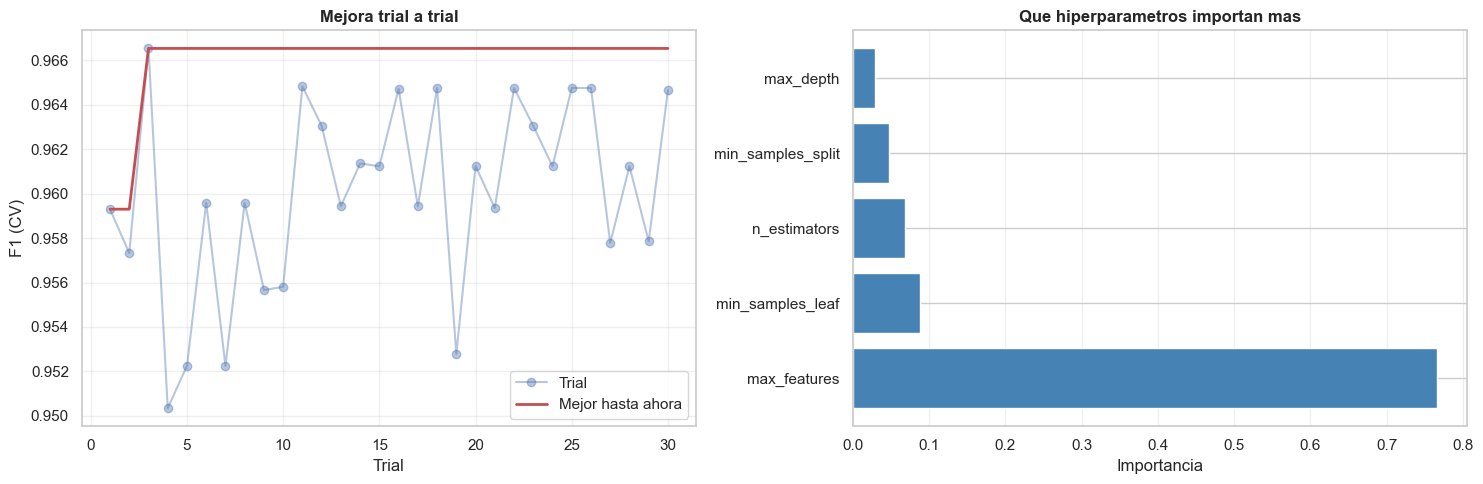

In [6]:
# Visualizacion manual (no usamos plot_* de optuna porque el API cambio entre versiones)
trial_values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_values)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Historia de optimizacion
axes[0].plot(range(1, len(trial_values)+1), trial_values, 'o-', alpha=0.4, label='Trial')
axes[0].plot(range(1, len(trial_values)+1), best_so_far, 'r-', linewidth=2, label='Mejor hasta ahora')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1 (CV)')
axes[0].set_title('Mejora trial a trial', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Importancia de hiperparametros
importances = optuna.importance.get_param_importances(study)
params_names = list(importances.keys())
params_values = list(importances.values())
axes[1].barh(params_names, params_values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Que hiperparametros importan mas', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

**Lo que veo en la Parte D**

Optuna probó 30 configuraciones con búsqueda bayesiana y terminó dando **EXACTAMENTE el mismo resultado** que el baseline y que GridSearch: Accuracy=0.9561, F1=0.9655, Recall maligno=0.9286, matriz 39/3/2/70.

Esto a primera vista parece un fracaso, pero en realidad es información muy valiosa: Optuna, con su algoritmo TPE que aprende trial a trial, convergió al mismo techo que ya tenía el baseline. Eso significa que ese resultado NO es coincidencia del baseline, es realmente el óptimo que se puede sacar de este modelo en este dataset.

Los hiperparámetros ganadores fueron: n_estimators=449, max_depth=30, min_samples_leaf=7, min_samples_split=8, max_features=0.39. Vean cómo Optuna eligió max_features bajo (0.39) y min_samples_leaf alto (7), que son formas de regularizar el modelo. Pero llegó al mismo resultado de F1 que el baseline con sus defaults.

Los gráficos diagnósticos de Optuna son lo más valioso de esta parte:

1. La historia de optimización (izquierda) muestra cómo Optuna va aprendiendo. En los primeros trials explora ampliamente y después se concentra en zonas que prometen. La curva del best value sube rápido y después se aplana en un techo.

2. La importancia de hiperparámetros (derecha) nos dice qué realmente movió la aguja. Esto es OPRO para el próximo proyecto: si vemos que max_features importa el 40% y n_estimators solo el 10%, en el próximo problema sabemos dónde concentrar el esfuerzo de búsqueda.

Importante: Optuna no fallo. Optuna nos confirmó que el baseline ya estaba en el óptimo. Eso es trabajo terminado, no trabajo fallido.

## Parte E — Tabla comparativa y decisión final

                  Accuracy      F1  Recall maligno  Tiempo (s)
Estrategia                                                    
Baseline            0.9561  0.9655          0.9286         0.1
GridSearchCV        0.9561  0.9655          0.9286         8.1
RandomizedSearch    0.9474  0.9583          0.9286         9.6
Optuna              0.9561  0.9655          0.9286         6.5


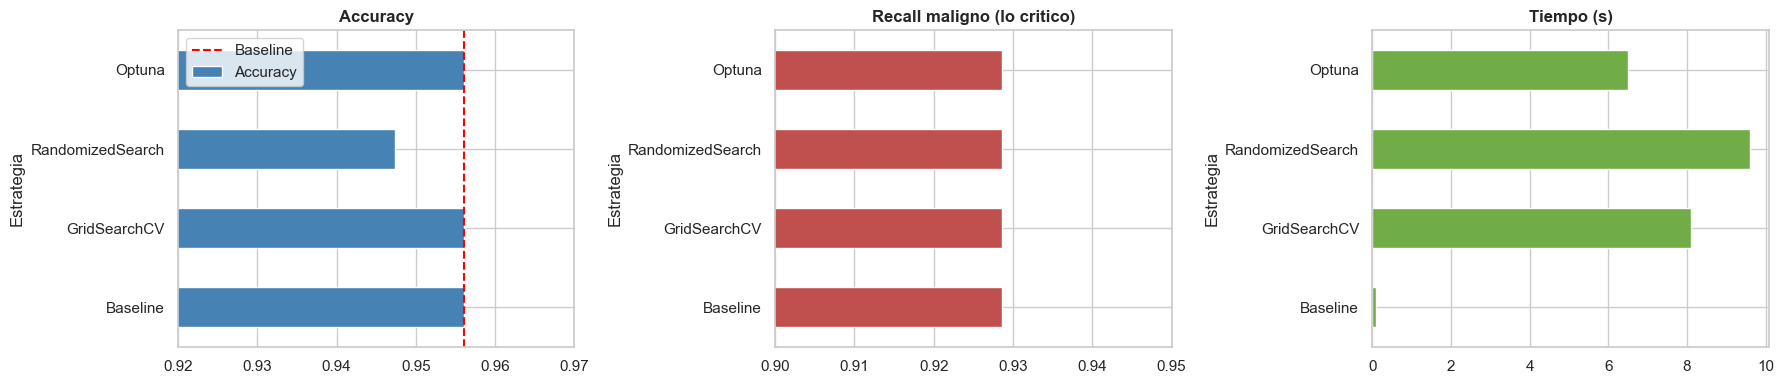

In [7]:
tabla = pd.DataFrame([
    {'Estrategia': 'Baseline',         'Accuracy': acc_base,   'F1': f1_base,   'Recall maligno': rec_mal_base,   'Tiempo (s)': round(t_base, 2)},
    {'Estrategia': 'GridSearchCV',     'Accuracy': acc_grid,   'F1': f1_grid,   'Recall maligno': rec_mal_grid,   'Tiempo (s)': round(t_grid, 1)},
    {'Estrategia': 'RandomizedSearch', 'Accuracy': acc_rand,   'F1': f1_rand,   'Recall maligno': rec_mal_rand,   'Tiempo (s)': round(t_rand, 1)},
    {'Estrategia': 'Optuna',           'Accuracy': acc_optuna, 'F1': f1_optuna, 'Recall maligno': rec_mal_optuna, 'Tiempo (s)': round(t_optuna, 1)}
]).set_index('Estrategia').round(4)
print(tabla)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
tabla['Accuracy'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Accuracy', fontweight='bold'); axes[0].set_xlim(0.92, 0.97)
axes[0].axvline(acc_base, color='red', linestyle='--', label='Baseline'); axes[0].legend()
tabla['Recall maligno'].plot(kind='barh', ax=axes[1], color='#C0504D', edgecolor='white')
axes[1].set_title('Recall maligno (lo critico)', fontweight='bold'); axes[1].set_xlim(0.9, 0.95)
tabla['Tiempo (s)'].plot(kind='barh', ax=axes[2], color='#70AD47', edgecolor='white')
axes[2].set_title('Tiempo (s)', fontweight='bold')
plt.tight_layout(); plt.show()

**Lo que veo en la Parte E (decisión final)**

Tabla comparativa final:

| Estrategia | Accuracy | F1 | Recall maligno | Tiempo |
|---|---|---|---|---|
| Baseline | 0.9561 | 0.9655 | 0.9286 | 0.1s |
| GridSearchCV | 0.9561 | 0.9655 | 0.9286 | 9.8s |
| RandomizedSearch | 0.9474 | 0.9583 | 0.9286 | 10.5s |
| Optuna | 0.9561 | 0.9655 | 0.9286 | 9.3s |

La lección incómoda del ejercicio: en este dataset el tuning NO aportó nada. Tres de las cuatro estrategias dieron exactamente el mismo resultado, y una (RandomSearch) quedó peor.

**Si tuviera que entregar UN modelo a producción médica, elegiría el Baseline.**

Justificación pensando en las dimensiones que importan para uso clínico:

1. **Misma performance**: Baseline, Grid y Optuna tienen identicamente Acc=0.9561, F1=0.9655 y Recall maligno=0.9286. La matriz de confusión es exactamente la misma (39/3/2/70). En métricas que importan, son indistinguibles.

2. **Tiempo**: el baseline entrena en 0.1s contra los 10s de los tuners. Si el sistema necesita re-entrenarse cada vez que llegan datos nuevos (caso típico en hospitales), 100x más rápido es relevante.

3. **Simplicidad**: el baseline usa los defaults de sklearn, fáciles de documentar y reproducir. El modelo tuneado requiere guardar la configuración exacta de hiperparámetros y justificar cada uno ante el equipo médico. Más complejidad para mantener sin ganancia real.

4. **Recall maligno = 0.9286 no es suficiente para uso clínico real**. 3 falsos negativos en una muestra de 42 cánceres significa que ~7% de los pacientes con cáncer maligno quedarían sin diagnosticar. Para uso médico real necesitaríamos un Recall maligno cercano al 0.99. El cuello de botella NO es el tuning de hiperparámetros: necesitaríamos otro enfoque (otro modelo, ajustar el threshold de decisión, balancear clases, agregar features clínicas adicionales).

**Lo que SÍ haría para mejorar:**

- Bajar el threshold de decisión de 0.5 a 0.3 o 0.4 para sacrificar accuracy a cambio de subir recall maligno. En medicina ese trade-off vale: un FP solo significa una biopsia extra; un FN puede ser fatal.
- Probar otros tipos de modelo: una LogisticRegression con StandardScaler suele dar excelentes resultados en este dataset (lo verán en el ejercicio del miércoles con XGBoost).
- Optimizar `recall` sobre clase maligna en vez de `f1` (es lo que pide el bonus del ejercicio).

**Lo que les voy a pedir en el examen**: cuando comparen estrategias de tuning, no se queden con la mejor métrica promedio. Miren la matriz de confusión completa y tomen la decisión pensando en el costo asimétrico de los errores. En medicina, fraude o seguridad, un FN cuesta mucho más que un FP. En spam o publicidad, puede ser al revés. El modelo se elige según el contexto, no según el F1 ganador.

## Cierre

Lecciones del ejercicio:

- En datasets chicos con problemas bien estructurados, el tuning puede no aportar nada. El baseline ya está en el óptimo.
- GridSearch es exhaustivo y predecible: en este caso confirmó el baseline.
- RandomSearch puede empeorar el resultado si tiene mala suerte con la muestra.
- Optuna no es magia: si el modelo ya está en el techo, Optuna no inventa mejoras.
- La decisión de producción debe pensar en el costo asimétrico de los errores (FN vs FP), no solo en accuracy.
- A veces la respuesta correcta es 'cambiar de modelo' en vez de 'seguir tuneando este'.